In [2]:
import torch
import gpytorch
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

In [3]:
# ─── 1. Generate toy data ───────────────────────────────
torch.manual_seed(42)

train_size = 200
error_scale = 0.1

X_train = torch.linspace(-2, 2, train_size).unsqueeze(1)

# f(x)=sin(x)+0.1ε
y_train = torch.sin(X_train).squeeze() + error_scale * torch.randn(train_size)    

In [4]:
# ─── 2. Define GP model ─────────────────────────────────
# Exact GP Model for small data, no approximation
# Prior: before seeing any data, f is a random function drawn from GP(c, k)
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, X_train, y_train, likelihood):
        super().__init__(X_train, y_train, likelihood)
        
        # Learn constant prior mean value during training, better than zero mean
        # It doesn't depend on x at all
        self.mean_module = gpytorch.means.ConstantMean()

        # Define covariance kernel function using RBF kernel
        # learnable scale l controls width of wiggles
        # learnable σf2 amplitude controls height of the wiggles
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    # Define prior distribution: What the GP believes about the function before seeing any data 
    # p(f | X)
    def forward(self, x):
        mean = self.mean_module(x) # calls constantmean and returns a vector of the constant c repeated N times
        covar = self.covar_module(x) # returns the NxN kernel matrix K
        return gpytorch.distributions.MultivariateNormal(
            mean, # type: ignore
            covar 
        )

In [5]:
# ─── 3. Train/Initialize hyperparameters ───────────────────────────

# Create likelihood object
likelihood = gpytorch.likelihoods.GaussianLikelihood()

# Initiate GP model
model = ExactGPModel(X_train, y_train, likelihood)

model.train()
likelihood.train()

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

In [6]:
# Create an Adam optimizer that will update all learnable parameters theta = (c,ℓ,σf2​,σn2​) with lr = 0.1
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# Define loss function, log of multivariate Gaussian PDF
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model) 

In [7]:
# Actual training loop
num_iters = 200
for i in range(num_iters):
    optimizer.zero_grad() # clear gradients from the previous iteration

    # Takes prior p(f|X) and add likelihood and compute log p(y|X, theta), sign - to minimize
    loss = -mll(model(X_train), y_train) # type: ignore
    
    # Compute gradients
    loss.backward() 

    # Update hyperparameters by ADAM momentum
    optimizer.step() 


print(f"Learned length scale: {model.covar_module.base_kernel.lengthscale.item():.4f}")
print(f"Learned noise:        {likelihood.noise.item():.4f}")


Learned length scale: 1.7371
Learned noise:        0.0097


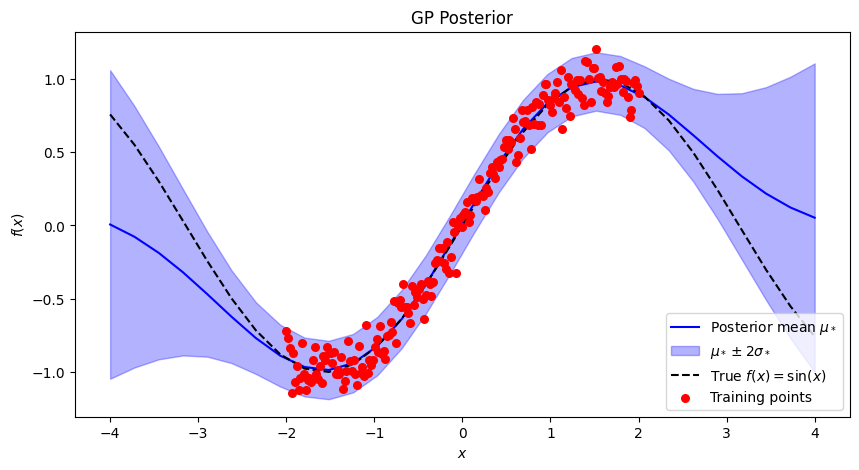

In [8]:
model.eval()
likelihood.eval()

# 1D test points
test_size = 30
function_num = 3

# shape (300, 1), wider than train to show uncertainty at edges
X_test = torch.linspace(-4, 4, test_size).unsqueeze(1)  

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood(model(X_test))
    mu  = pred.mean.numpy()              # shape (300,)
    std = pred.variance.sqrt().numpy()   # shape (300,)
    # resample functions
    samples = pred.sample(sample_shape=torch.Size([function_num])).numpy()

x_plot = X_test.squeeze().numpy()

plt.figure(figsize=(10, 5))

# mean
plt.plot(x_plot, mu, 'b-', label='Posterior mean $\\mu_*$')

# uncertainity
plt.fill_between(x_plot, mu - 2*std, mu + 2*std, alpha=0.3, color='blue', label='$\\mu_* \\pm 2\\sigma_*$')

# without error
plt.plot(x_plot, np.sin(x_plot), 'k--', label='True $f(x) = \\sin(x)$')

plt.scatter(X_train.squeeze().numpy(), y_train.numpy(), c='red', s=30, zorder=5, label='Training points')
plt.legend()
plt.title('GP Posterior')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.show()

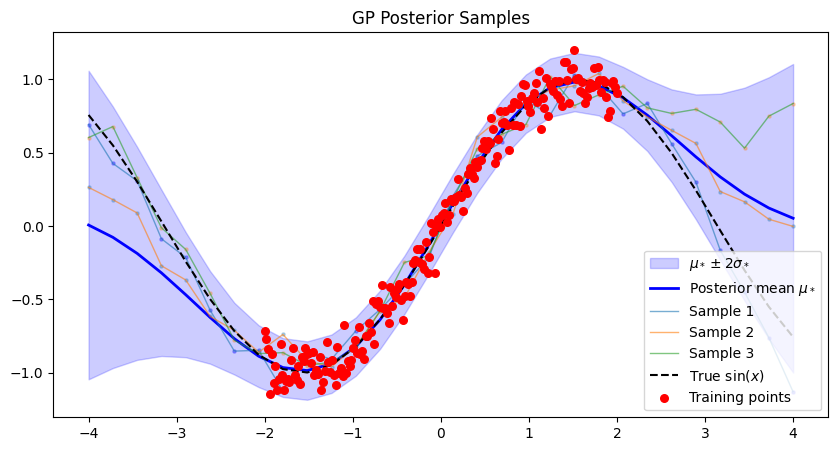

In [12]:
plt.figure(figsize=(10, 5))

# Uncertainty band
plt.fill_between(x_plot, mu - 2*std, mu + 2*std, alpha=0.2, color='blue', label='$\\mu_* \\pm 2\\sigma_*$')

# Posterior mean
plt.plot(x_plot, mu, 'b-', linewidth=2, label='Posterior mean $\\mu_*$')

# Sampled functions
for i, s in enumerate(samples):
    color = plt.gca().lines[-1].get_color()
    plt.plot(x_plot, s, alpha=0.6, linewidth=1, label=f'Sample {i+1}')
    plt.scatter(x_plot, s, alpha=0.3, s=5, color=color)


# True function and training points
plt.plot(x_plot, np.sin(x_plot), 'k--', label='True $\\sin(x)$')
plt.scatter(X_train.squeeze().numpy(), y_train.numpy(), c='red', s=30, zorder=5, label='Training points')

plt.legend()
plt.title('GP Posterior Samples')
plt.show()

In [11]:
samples[1].shape

(30,)